# 13 — Selección Final del Modelo

## Introducción

**Objetivo.** Seleccionar el modelo recomendado para PREDIA con criterios clínicos y operativos.

**Fundamento teórico.** La selección balancea desempeño (AUC, sensibilidad), robustez, interpretabilidad y coste.

**Ventajas.** Decisión trazable y justificada para producción.

**Limitaciones.** Depende del marco de features elegido (screening honesto vs clinical).

**Casos de uso.** Cierre del ciclo experimental antes de desplegar.


In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('../src'))
import warnings; warnings.simplefilter('ignore')
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from predia_ml import config, data, evaluate, plots
pd.set_option('display.max_columns', 60)


In [2]:
comp = pd.read_json(config.METRICS_DIR/'comparison_screening.json').sort_values('roc_auc', ascending=False)
card = json.load(open(config.EXPORTS_DIR/'model_card.json'))
print('Modelo seleccionado:', card['model_name'], '| marco:', card['framing'])
comp[['model','roc_auc','recall_sensitivity','specificity','f1','mcc']].reset_index(drop=True)

Modelo seleccionado: logistic_regression | marco: screening (sin laboratorios diagnósticos — honesto)


,model,roc_auc,recall_sensitivity,specificity,f1,mcc
0,logistic_regression,0.6591,0.5675,0.6597,0.6325,0.2229
1,hist_gradient_boosting,0.6579,0.8391,0.3189,0.7318,0.1856
2,xgboost,0.6573,0.8317,0.3246,0.7289,0.1817
3,lightgbm,0.6558,0.8387,0.3119,0.7301,0.1776
4,random_forest,0.6549,0.8848,0.2340,0.7387,0.1576
5,extra_trees,0.6538,0.9220,0.1656,0.7441,0.1356
6,mlp,0.6530,0.7937,0.3704,0.7172,0.1807
7,svm,0.6328,0.9600,0.0907,0.7482,0.1044
8,knn,0.5845,0.8251,0.2631,0.7124,0.1061


### Interpretabilidad: Permutation Importance

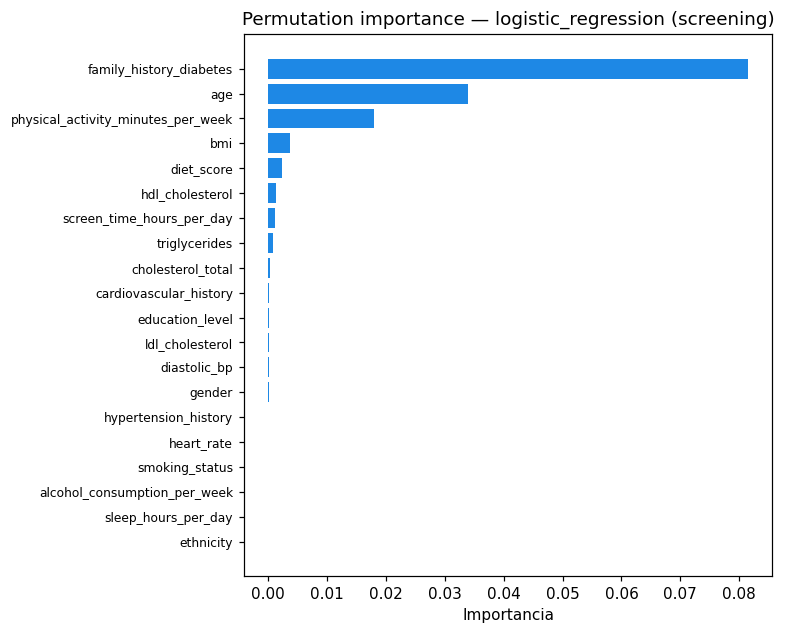

,feature,importance_mean,importance_std
0,family_history_diabetes,0.081571,0.002390
1,age,0.033991,0.001309
2,physical_activity_minutes_per_week,0.017938,0.001614
3,bmi,0.003742,0.000478
4,diet_score,0.002262,0.000535
5,hdl_cholesterol,0.001268,0.000489
6,screen_time_hours_per_day,0.001221,0.000262
7,triglycerides,0.000784,0.000222
8,cholesterol_total,0.000320,0.000107
9,cardiovascular_history,0.000208,0.000134


In [3]:
display(Image(filename=str(config.FIGURES_DIR/'interpretability'/'permutation_importance.png')))
pd.read_json(config.METRICS_DIR/'permutation_importance.json').head(10)

### Interpretabilidad: SHAP

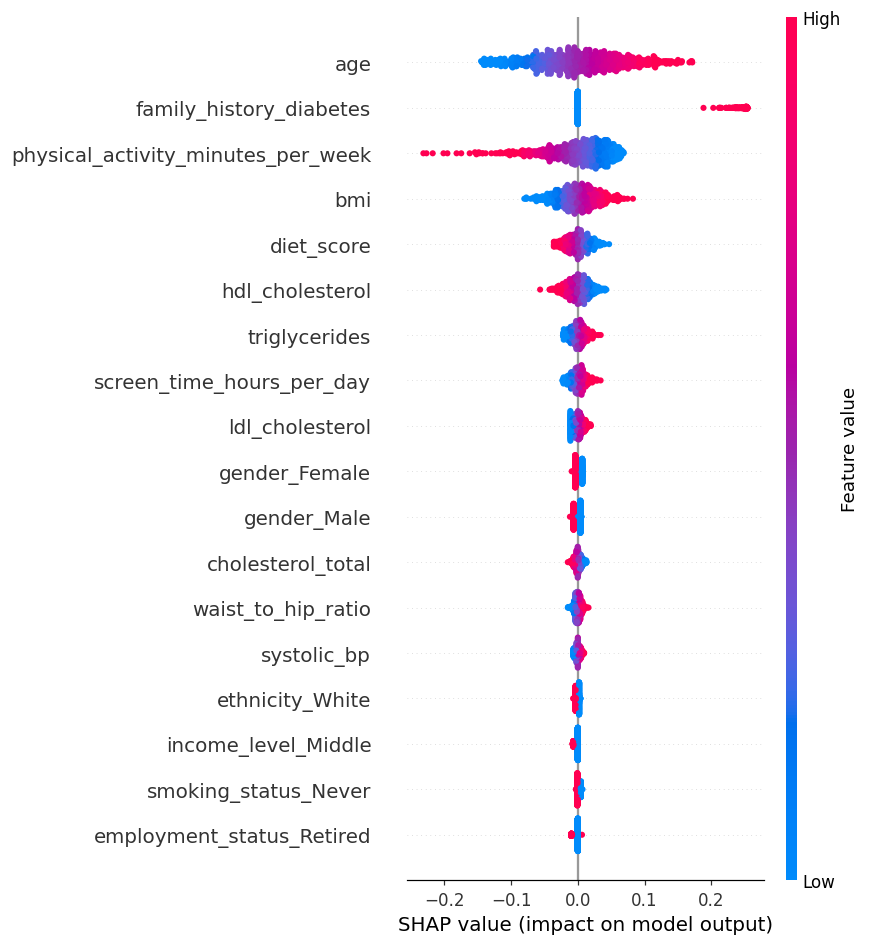

In [4]:
p = config.FIGURES_DIR/'interpretability'/'shap_summary.png'
display(Image(filename=str(p))) if p.exists() else print('SHAP no disponible')

### Implicaciones clínicas
Las variables más influyentes (antropometría, antecedentes, estilo de vida) son **modificables/registrables** sin laboratorio, lo que da valor real al cribado. Riesgo de interpretación: importancia ≠ causalidad.